In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel('Heart Disease.xlsx')
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


In [ ]:
#pip install --upgrade openpyxl


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  int64  
 6   MentalHealth      319795 non-null  int64  
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  int64  
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [ ]:
#pip install openpyxl

In [4]:
df.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

In [5]:
df.duplicated().sum()

18078

In [137]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(),annot=True)

<Axes: xlabel='Smoking', ylabel='count'>

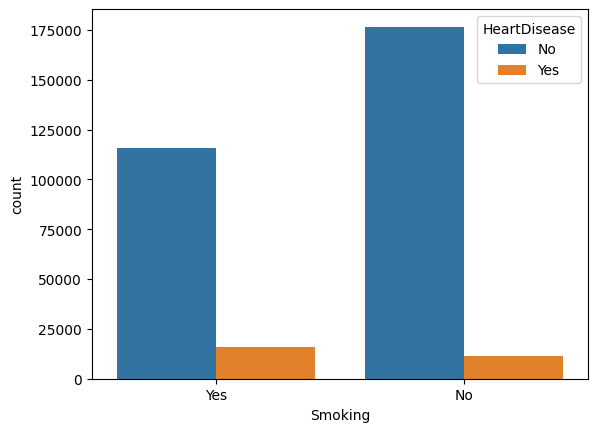

In [10]:
#sns.countplot(df.HeartDisease)
sns.countplot(x='Smoking',hue='HeartDisease',data=df)

# NB: The Dataset is not balanced.

In [6]:
data = df[df['HeartDisease']=='Yes']
data

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
5,Yes,28.87,Yes,No,No,6,0,Yes,Female,75-79,Black,No,No,Fair,12,No,No,No
10,Yes,34.30,Yes,No,No,30,0,Yes,Male,60-64,White,Yes,No,Poor,15,Yes,No,No
35,Yes,32.98,Yes,No,Yes,10,0,Yes,Male,75-79,White,Yes,Yes,Poor,4,No,No,Yes
42,Yes,25.06,No,No,No,0,0,Yes,Female,80 or older,White,Yes,No,Good,7,No,No,Yes
43,Yes,30.23,Yes,No,No,6,2,Yes,Female,75-79,White,Yes,Yes,Fair,8,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319765,Yes,38.45,No,No,Yes,30,15,Yes,Female,55-59,Hispanic,Yes,Yes,Poor,6,Yes,No,No
319767,Yes,36.21,Yes,No,No,0,0,Yes,Female,75-79,Hispanic,Yes,Yes,Good,8,No,No,No
319781,Yes,37.12,Yes,No,No,0,0,No,Male,35-39,Hispanic,No,Yes,Very good,7,No,No,No
319786,Yes,33.20,Yes,No,No,0,0,No,Female,60-64,Hispanic,Yes,Yes,Very good,8,Yes,No,No


In [7]:
smoke=data['Smoking'].value_counts()
smoke

Smoking
Yes    16037
No     11336
Name: count, dtype: int64

In [8]:
labels=["No",'Yes']

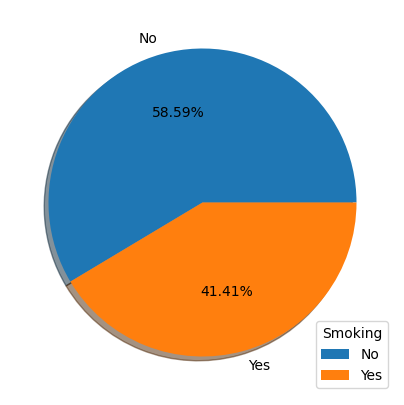

In [9]:
plt.figure(figsize=(5,5))
plt.pie(smoke,labels=labels,autopct='%2.2f%%',shadow=True)#autopct enables you to display the percent value using Python string formatting
plt.legend(title='Smoking',loc='lower right')
plt.show()

In [10]:
def  bar_chart(feature):
    live=df[df['HeartDisease']=='No'][feature].value_counts()
    die=df[df['HeartDisease']=='Yes'][feature].value_counts()
    df1=pd.DataFrame([live,die])
    df1.index=['Live','Die']
    df1.plot(kind='bar',figsize=(10,5))

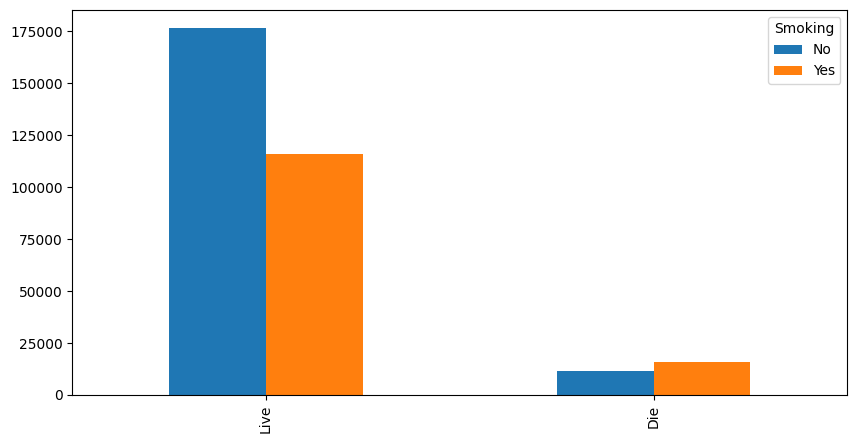

In [11]:
bar_chart('Smoking')

<Axes: xlabel='BMI', ylabel='Density'>

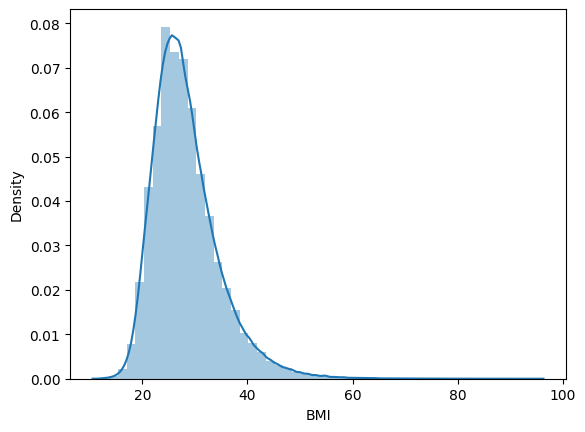

In [12]:
sns.distplot(df['BMI']) #A Distplot or distribution plot, depicts the variation in the data distribution.

In [13]:
def kde(x):
    facet=sns.FacetGrid(df,hue="HeartDisease",aspect=4)
    facet.map(sns.kdeplot,x,shade=True)
    facet.set(xlim=(df[x].min(),df[x].max()))#Limits for each of the axes on each facet (only relevant when share{x, y} is True).
    facet.add_legend()
    plt.show()

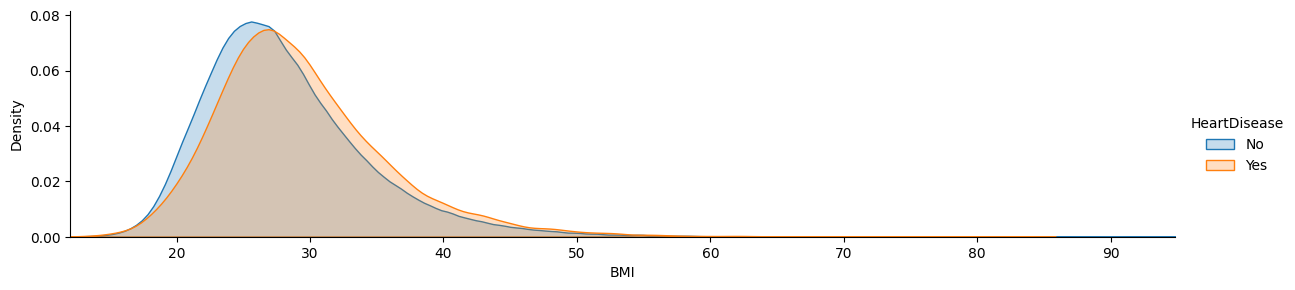

In [14]:
kde('BMI')

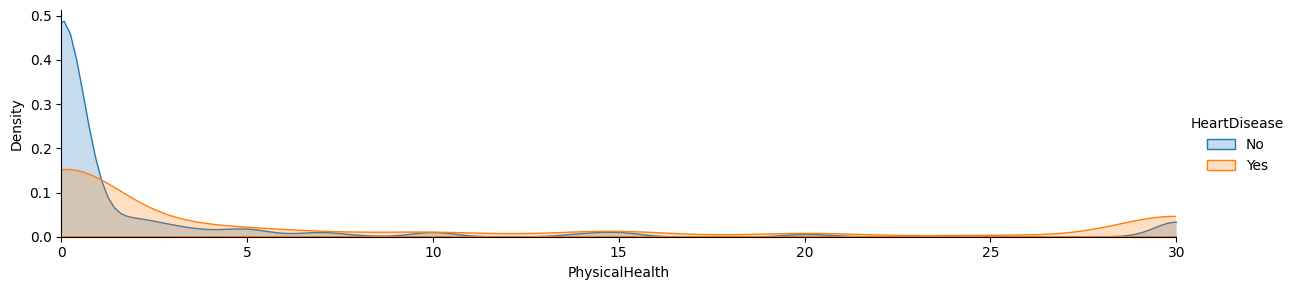

In [15]:
kde('PhysicalHealth')

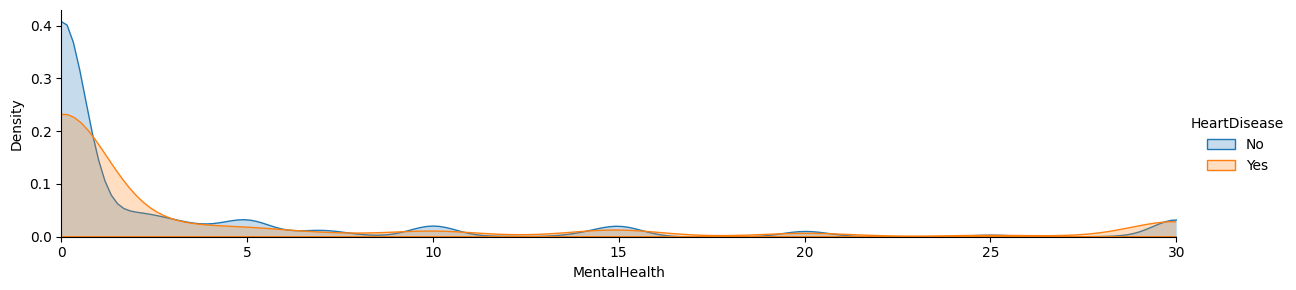

In [16]:
kde('MentalHealth')

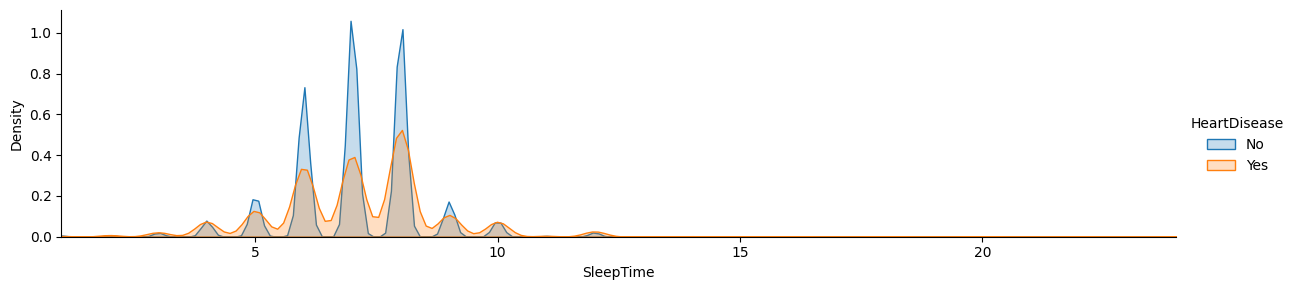

In [17]:
kde('SleepTime')

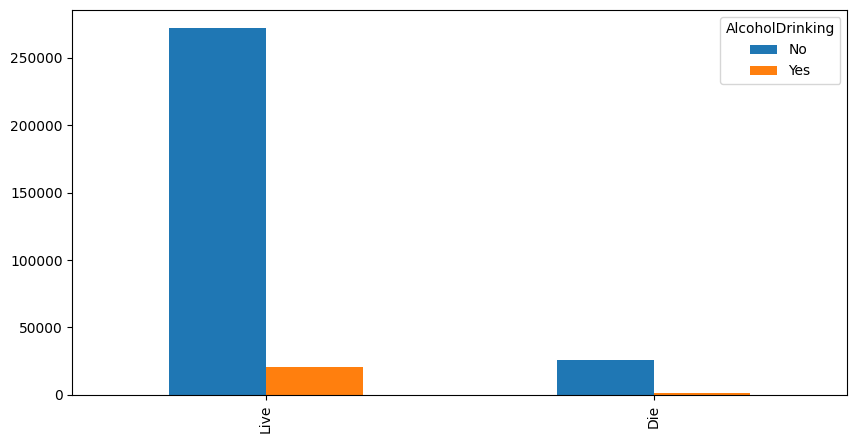

In [18]:
bar_chart('AlcoholDrinking')

In [19]:
AlcoholDrinking=data['AlcoholDrinking'].value_counts()
AlcoholDrinking

AlcoholDrinking
No     26232
Yes     1141
Name: count, dtype: int64

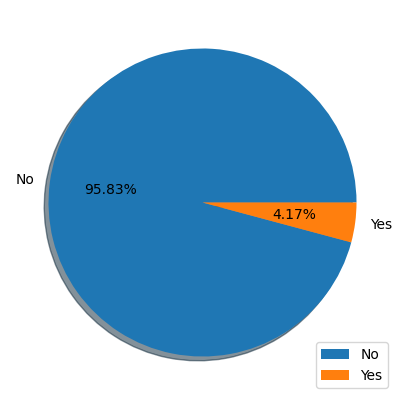

In [20]:
plt.figure(figsize=(5,5))
plt.pie(AlcoholDrinking,labels=labels,autopct='%2.2f%%',shadow=True)#autopct enables you to display the percent value using Python string formatting
plt.legend(title='',loc='lower right')
plt.show()

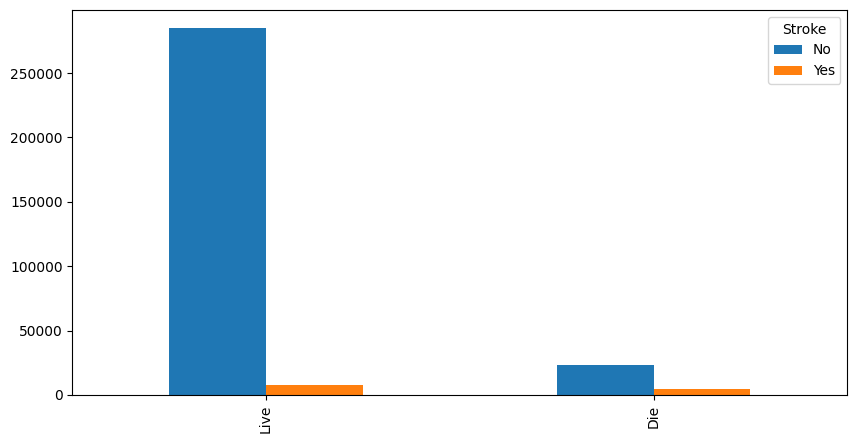

In [21]:
bar_chart('Stroke')

In [22]:
Stroke=data['Stroke'].value_counts()
Stroke

Stroke
No     22984
Yes     4389
Name: count, dtype: int64

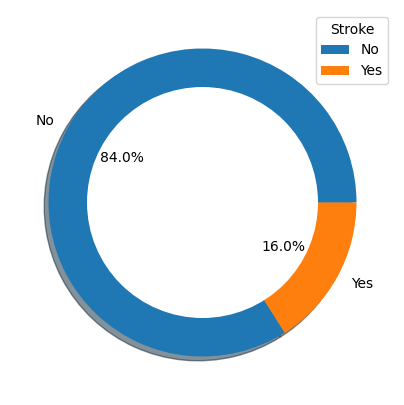

In [23]:
plt.figure(figsize=(5,5))
plt.pie(Stroke,labels=labels,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.75,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='Stroke',loc='upper right')
plt.show()

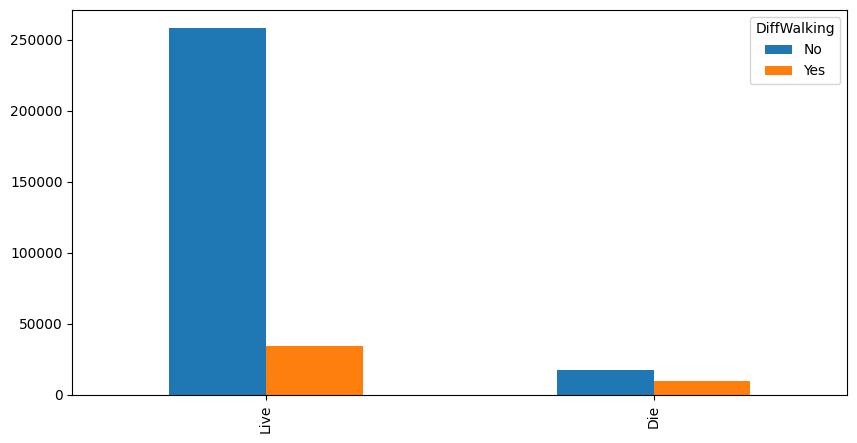

In [24]:
bar_chart('DiffWalking')

In [25]:
DiffWalking=data['DiffWalking'].value_counts()

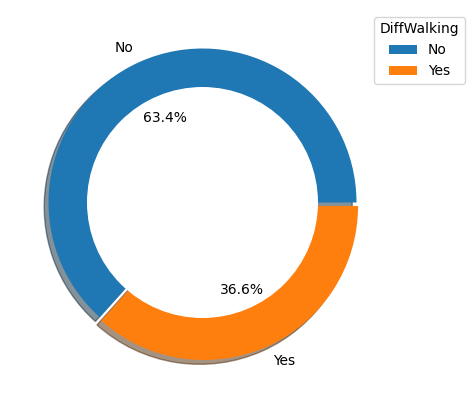

In [26]:
plt.figure(figsize=(5,5))
plt.pie(DiffWalking,labels=labels,explode=[0,0.025] ,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.75,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='DiffWalking',loc='upper right',bbox_to_anchor=(1.2,1))
plt.show()

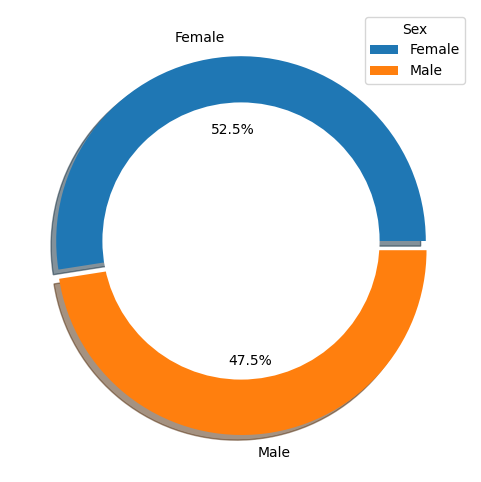

In [27]:
Sex=df['Sex'].value_counts()
Sex
labels=['Female','Male']
plt.figure(figsize=(6,6))
plt.pie(Sex,labels=labels,explode=[0,0.05] ,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.75,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='Sex',loc='upper right')
plt.show()

In [28]:
Race=df['Race'].value_counts()
Race

Race
White                             245212
Hispanic                           27446
Black                              22939
Other                              10928
Asian                               8068
American Indian/Alaskan Native      5202
Name: count, dtype: int64

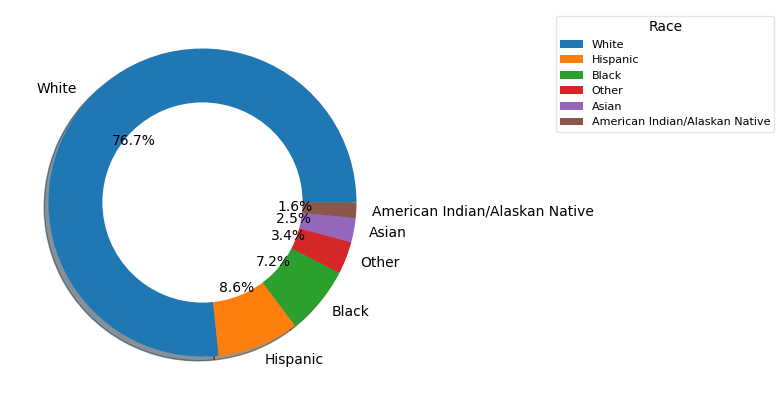

In [29]:
labels=['White','Hispanic','Black','Other','Asian','American Indian/Alaskan Native']
plt.figure(figsize=(5,5))
plt.pie(Race,labels=labels,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.65,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='Race',loc='upper right',framealpha=0.5,fontsize=8,bbox_to_anchor=(2,1))
plt.show()

In [30]:
PhysicalActivity=df['PhysicalActivity'].value_counts()
PhysicalActivity

PhysicalActivity
Yes    247957
No      71838
Name: count, dtype: int64

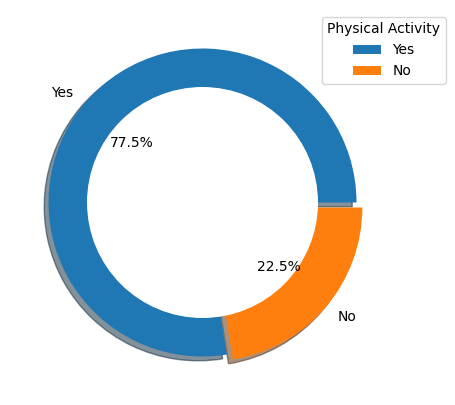

In [31]:
labels=['Yes','No']
plt.figure(figsize=(5,5))
plt.pie(PhysicalActivity,labels=labels,explode=[0,0.05] ,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.75,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='Physical Activity',loc='upper right',bbox_to_anchor=(1.15,1))
plt.show()

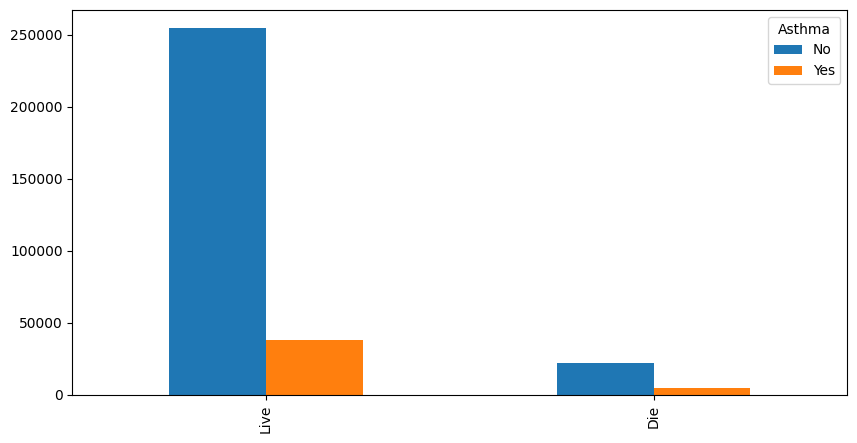

In [32]:
bar_chart('Asthma')


In [33]:
SkinCancer=data['SkinCancer'].value_counts()
SkinCancer

SkinCancer
No     22393
Yes     4980
Name: count, dtype: int64

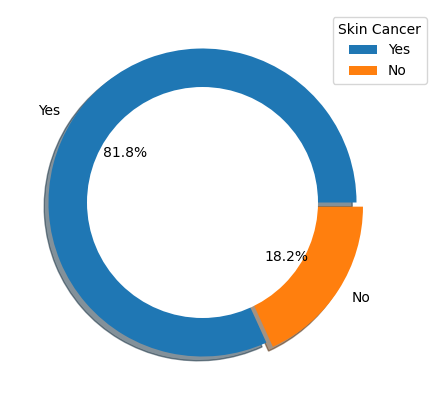

In [34]:
plt.figure(figsize=(5,5))
plt.pie(SkinCancer,labels=labels,explode=[0,0.05] ,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.75,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='Skin Cancer',loc='upper right',bbox_to_anchor=(1.1,1))
plt.show()

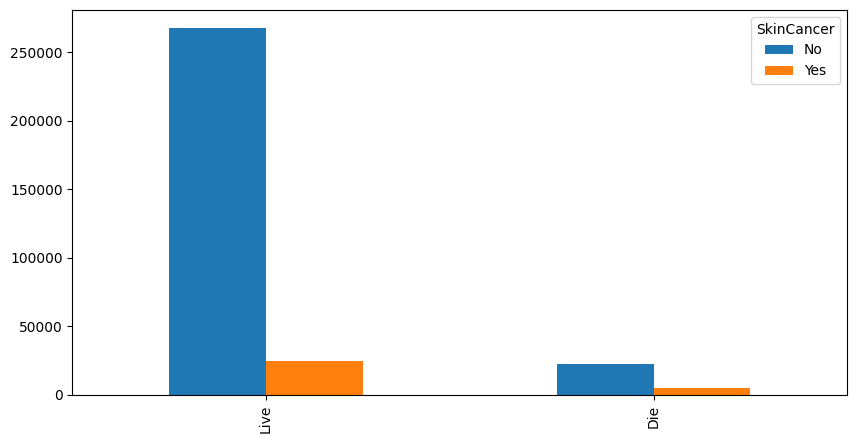

In [35]:
 bar_chart('SkinCancer')

# Data preprocessing for balancing


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error,accuracy_score

In [37]:
from sklearn.preprocessing import LabelEncoder

In [38]:
le=LabelEncoder()

In [39]:
list=['HeartDisease','Smoking', 'AlcoholDrinking', 'Stroke','DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']
for i in list:
    df[i]=le.fit_transform(df[i])

In [40]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3,30,0,0,7,5,2,1,4,5,1,0,1
1,0,20.34,0,0,1,0,0,0,0,12,5,0,1,4,7,0,0,0
2,0,26.58,1,0,0,20,30,0,1,9,5,2,1,1,8,1,0,0
3,0,24.21,0,0,0,0,0,0,0,11,5,0,0,2,6,0,0,1
4,0,23.71,0,0,0,28,0,1,0,4,5,0,1,4,8,0,0,0


In [41]:
x=df.drop(columns=['HeartDisease'])
y=df['HeartDisease']

In [42]:
x.sample(10)

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
261448,32.92,0,0,0,30,10,1,0,12,3,2,0,1,6,1,0,0
244882,38.01,0,0,0,0,0,0,0,5,5,0,1,4,7,0,0,0
31742,25.06,0,0,0,0,0,0,0,2,5,0,1,2,8,0,0,0
49855,28.06,1,0,0,0,3,0,1,3,5,0,1,4,5,0,0,0
29180,23.37,0,0,0,0,0,0,1,6,5,0,1,4,6,1,0,0
37074,31.32,0,0,0,0,0,0,1,4,3,0,1,0,8,0,0,0
108312,28.89,1,0,0,0,0,0,1,5,5,0,1,2,6,0,0,0
281833,28.29,1,0,0,0,0,0,0,12,5,0,0,2,8,0,0,0
216386,43.19,0,0,0,30,0,0,1,11,5,2,1,1,8,0,1,0
296518,20.78,0,0,0,0,0,0,0,4,5,0,1,0,8,0,0,0


# Undersampling

In [45]:
#from imblearn.under_sampling import NearMiss

In [51]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [46]:
#NearMiss_obj = NearMiss()
#new_x , new_y = NearMiss_obj.fit_resample(x,y)

In [48]:
#new_y

0        0
1        0
2        0
3        0
4        0
        ..
54741    1
54742    1
54743    1
54744    1
54745    1
Name: HeartDisease, Length: 54746, dtype: int32

In [49]:
#new_y.value_counts()

0    27373
1    27373
Name: HeartDisease, dtype: int64

In [47]:
#df2=pd.DataFrame(new_x)
#df2.head()


In [48]:
#df3=pd.DataFrame(new_y)
#df3.head()

In [49]:
#df4=pd.concat([df2,df3],axis=1)
#df4

# Feature ranking


In [50]:
#df4.nunique()

In [51]:
from sklearn.ensemble import ExtraTreesClassifier # Decison tree

In [52]:
extr = ExtraTreesClassifier()

In [53]:
extr.fit(x,y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [54]:
feature_importance = extr.feature_importances_
feature_importance  

array([0.34251032, 0.01322736, 0.00761254, 0.03029251, 0.07886448,
       0.07653534, 0.02622013, 0.0161149 , 0.10301404, 0.03810331,
       0.02677608, 0.0168983 , 0.05712142, 0.12571395, 0.01507539,
       0.01389632, 0.0120236 ])

In [57]:
imp = pd.DataFrame(feature_importance, columns=['Gain_Score'])
imp.head(18)

,Gain_Score
0,0.342510
1,0.013227
2,0.007613
3,0.030293
4,0.078864
5,0.076535
6,0.026220
7,0.016115
8,0.103014
9,0.038103


In [56]:
x.columns

Index(['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth',
       'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic',
       'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease',
       'SkinCancer'],
      dtype='object')

In [58]:
cols = pd.DataFrame(x.columns, columns=['Feature_Names'])
cols.head(18)

,Feature_Names
0,BMI
1,Smoking
2,AlcoholDrinking
3,Stroke
4,PhysicalHealth
5,MentalHealth
6,DiffWalking
7,Sex
8,AgeCategory
9,Race


In [59]:
gains = pd.concat([cols,imp],axis=1)
gains

,Feature_Names,Gain_Score
0,BMI,0.342510
1,Smoking,0.013227
2,AlcoholDrinking,0.007613
3,Stroke,0.030293
4,PhysicalHealth,0.078864
5,MentalHealth,0.076535
6,DiffWalking,0.026220
7,Sex,0.016115
8,AgeCategory,0.103014
9,Race,0.038103


In [60]:
newx = gains.nlargest(18,'Gain_Score')
newx

,Feature_Names,Gain_Score
0,BMI,0.342510
13,SleepTime,0.125714
8,AgeCategory,0.103014
4,PhysicalHealth,0.078864
5,MentalHealth,0.076535
12,GenHealth,0.057121
9,Race,0.038103
3,Stroke,0.030293
10,Diabetic,0.026776
6,DiffWalking,0.026220


<Axes: xlabel='Gain_Score', ylabel='Feature_Names'>

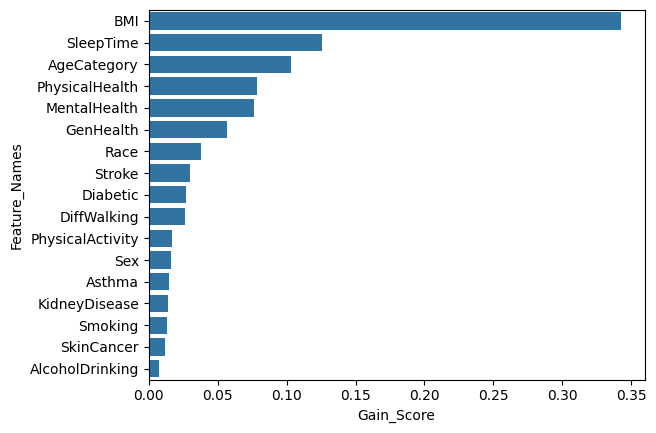

In [61]:
sns.barplot(x='Gain_Score',y='Feature_Names',data=newx)


<Axes: >

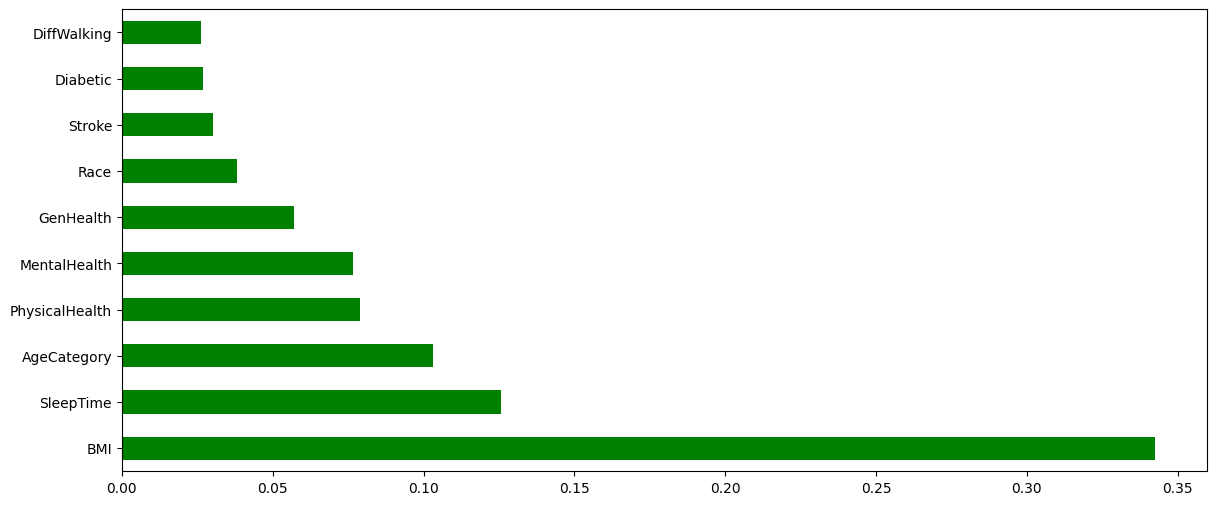

In [63]:
features = pd.Series(extr.feature_importances_, index = x.columns)
plt.figure(figsize=(14,6))
features.nlargest(10).plot(kind='barh', color='g')

# Split Dataset into Train and Test


In [69]:
from sklearn.model_selection import train_test_split

In [93]:
!pip install imbalanced-learn


In [102]:
import numpy as np

# ---------------- Manual oversampling function ----------------
def oversample(x, y):
    unique, counts = np.unique(y, return_counts=True)
    max_count = max(counts)
    x_res, y_res = [], []

    for cls in unique:
        x_cls = x[y == cls]
        y_cls = y[y == cls]
        reps = max_count // len(x_cls)
        rem = max_count % len(x_cls)
        x_res.append(np.tile(x_cls, (reps, 1)))
        y_res.append(np.tile(y_cls, reps))
        if rem > 0:
            x_res.append(x_cls[:rem])
            y_res.append(y_cls[:rem])

    x_res = np.vstack(x_res)
    y_res = np.hstack(y_res)

    # Shuffle
    idx = np.arange(len(x_res))
    np.random.shuffle(idx)
    return x_res[idx], y_res[idx]

# ---------------- Apply oversampling ----------------
# x and y contain your original dataset
x_bal, y_bal = oversample(x, y)

# ---------------- Separate for model training ----------------
x = x_bal
y = y_bal

# Optional: check new class counts
unique, counts = np.unique(y, return_counts=True)
print("Balanced class counts:", dict(zip(unique, counts)))


Balanced class counts: {0: 292422, 1: 292422}


In [104]:
import pandas as pd

y_series = pd.Series(y)
print(y_series.value_counts())


1    292422
0    292422
Name: count, dtype: int64


In [105]:
print("x shape after oversampling:", x.shape)


x shape after oversampling: (584844, 17)


In [107]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y_series,train_size=0.8,random_state=42)

In [138]:
#xtest.head(50)

In [72]:
ytest.head(50)

271884    0
270361    0
219060    0
24010     0
181930    0
24149     1
185683    0
316656    0
305719    0
56786     0
240362    0
166773    0
156799    0
259623    0
220344    0
189010    0
301058    0
156366    0
42895     0
199052    0
221416    0
235723    1
223475    0
326       0
299663    0
75739     0
231975    0
36369     0
230715    0
142340    0
210513    0
968       1
227857    0
29693     1
223339    0
306225    0
154015    0
239020    0
265163    0
187674    0
182226    0
231958    0
199131    0
199866    0
22980     0
17826     0
47898     1
67985     0
89189     0
219846    0
Name: HeartDisease, dtype: int32

Round 1: Loss=0.5128, Accuracy=0.7604
Round 2: Loss=0.4947, Accuracy=0.7609
Round 3: Loss=0.4918, Accuracy=0.7633
Round 4: Loss=0.4923, Accuracy=0.7632
Round 5: Loss=0.4907, Accuracy=0.7646
Round 6: Loss=0.4895, Accuracy=0.7642
Round 7: Loss=0.4885, Accuracy=0.7651
Round 8: Loss=0.4883, Accuracy=0.7654
Round 9: Loss=0.4873, Accuracy=0.7660
Round 10: Loss=0.4851, Accuracy=0.7664
Round 11: Loss=0.4843, Accuracy=0.7670
Round 12: Loss=0.4838, Accuracy=0.7666
Round 13: Loss=0.4828, Accuracy=0.7676
Round 14: Loss=0.4822, Accuracy=0.7676
Round 15: Loss=0.4818, Accuracy=0.7681
Round 16: Loss=0.4809, Accuracy=0.7682
Round 17: Loss=0.4806, Accuracy=0.7678
Round 18: Loss=0.4794, Accuracy=0.7687
Round 19: Loss=0.4788, Accuracy=0.7690
Round 20: Loss=0.4778, Accuracy=0.7695

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.72      0.76     58486
           1       0.75      0.82      0.78     58483

    accuracy                           0

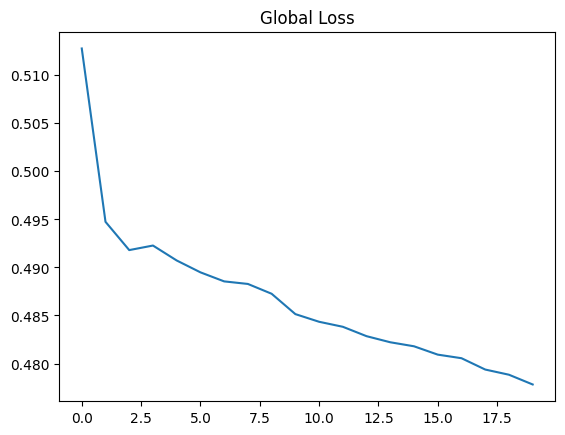

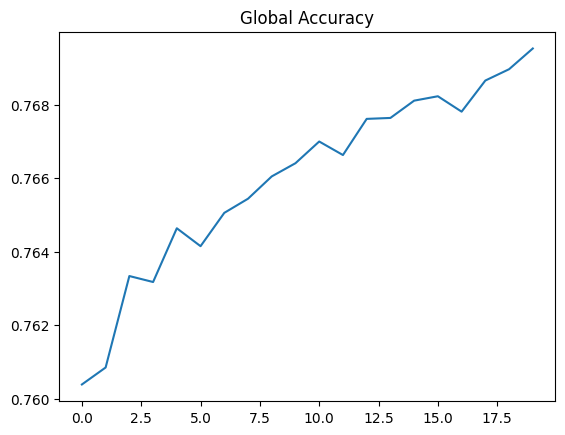

In [109]:
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Split data into clients
# -----------------------------
def split_clients(X, y, n_clients=5):
    idx = np.arange(len(X)); np.random.shuffle(idx)
    return [(X[s], y[s]) for s in np.array_split(idx, n_clients)]

# -----------------------------
# 2. Build 1D CNN
# -----------------------------
def build_1dcnn(input_shape, n_classes):
    model = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# -----------------------------
# 3. FedAvg aggregation
# -----------------------------
def fedavg(global_model, local_models, sizes):
    total = np.sum(sizes)
    new_weights = [sum(w*s for w, s in zip(ws, sizes)) / total
                   for ws in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -----------------------------
# 4. FedAvg training + metrics
# -----------------------------
def model_fedavg_1dcnn(xtrain, ytrain, xtest, ytest, n_clients=5, rounds=5, epochs=1):

    # Convert DataFrames/Series to NumPy arrays
    xtrain = xtrain.to_numpy() if hasattr(xtrain, "to_numpy") else np.array(xtrain)
    xtest  = xtest.to_numpy()  if hasattr(xtest, "to_numpy") else np.array(xtest)
    ytrain = ytrain.to_numpy() if hasattr(ytrain, "to_numpy") else np.array(ytrain)
    ytest  = ytest.to_numpy()  if hasattr(ytest, "to_numpy") else np.array(ytest)

    # Reshape to 3D for Conv1D
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    clients = split_clients(xtrain, ytrain, n_clients)
    global_model = build_1dcnn(xtrain.shape[1:], len(np.unique(ytrain)))
    global_loss, global_acc = [], []

    for r in range(rounds):
        local_models, sizes = [], []
        for Xc, yc in clients:
            lm = clone_model(global_model)
            lm.set_weights(global_model.get_weights())
            lm.compile(Adam(0.001), 'sparse_categorical_crossentropy', ['accuracy'])
            lm.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(lm)
            sizes.append(len(Xc))
        global_model = fedavg(global_model, local_models, sizes)
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss); global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
    print("\nGlobal Loss per Round:", global_loss)
    print("Global Accuracy per Round:", global_acc)

    plt.figure(); plt.plot(global_loss); plt.title("Global Loss"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
# Just call the function directly on your DataFrames / Series
global_model = model_fedavg_1dcnn(xtrain, ytrain, xtest, ytest, n_clients=4, rounds=20, epochs=2)


In [132]:
global_loss_per_round_CNN = [0.5127788782119751, 0.49474450945854187, 0.49180155992507935, 0.49227553606033325, 0.49072057008743286, 0.4894871711730957, 0.48854556679725647, 0.4882791042327881, 0.4872584342956543, 0.4851415157318115, 0.4843437969684601, 0.48382264375686646, 0.482844740152359, 0.4822111129760742, 0.481793075799942, 0.48092523217201233, 0.48055219650268555, 0.4793736934661865, 0.47883424162864685, 0.4778195321559906]


In [133]:
global_accuracy_per_round_CNN = [0.760389506816864, 0.7608511447906494, 0.7633389830589294, 0.7631765604019165, 0.7646384835243225, 0.7641511559486389, 0.765057384967804, 0.7654421329498291, 0.7660491466522217, 0.7664082050323486, 0.7669981122016907, 0.7666304707527161, 0.7676136493682861, 0.7676392793655396, 0.7681095004081726, 0.7682291865348816, 0.7678102850914001, 0.7686566710472107, 0.768964409828186, 0.7695286870002747]


Round 1: Loss=0.5762, Accuracy=0.7359
Round 2: Loss=0.4933, Accuracy=0.7636
Round 3: Loss=0.4909, Accuracy=0.7644
Round 4: Loss=0.4888, Accuracy=0.7652
Round 5: Loss=0.4889, Accuracy=0.7641
Round 6: Loss=0.4867, Accuracy=0.7674
Round 7: Loss=0.4858, Accuracy=0.7675
Round 8: Loss=0.4844, Accuracy=0.7684
Round 9: Loss=0.4839, Accuracy=0.7689
Round 10: Loss=0.4816, Accuracy=0.7686
Round 11: Loss=0.4815, Accuracy=0.7701
Round 12: Loss=0.4775, Accuracy=0.7709
Round 13: Loss=0.4763, Accuracy=0.7702
Round 14: Loss=0.4741, Accuracy=0.7715
Round 15: Loss=0.4718, Accuracy=0.7735
Round 16: Loss=0.4674, Accuracy=0.7746
Round 17: Loss=0.4644, Accuracy=0.7762
Round 18: Loss=0.4607, Accuracy=0.7770
Round 19: Loss=0.4593, Accuracy=0.7792
Round 20: Loss=0.4537, Accuracy=0.7810

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.73      0.77     58486
           1       0.76      0.83      0.79     58483

    accuracy                           0

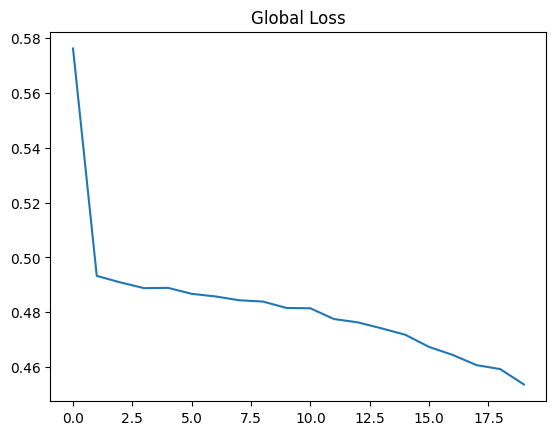

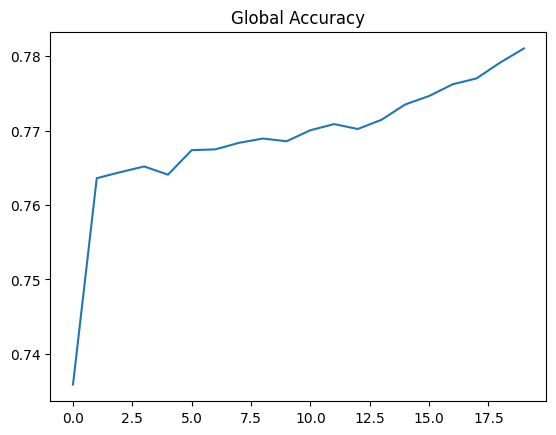

In [114]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Split data into clients
# -----------------------------
def split_clients(X, y, n_clients=5):
    idx = np.arange(len(X)); np.random.shuffle(idx)
    return [(X[s], y[s]) for s in np.array_split(idx, n_clients)]

# -----------------------------
# 2. Build LSTM model
# -----------------------------
def build_lstm(input_shape, n_classes):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# -----------------------------
# 3. FedAvg aggregation
# -----------------------------
def fedavg(global_model, local_models, sizes):
    total = np.sum(sizes)
    new_weights = [sum(w*s for w, s in zip(ws, sizes)) / total
                   for ws in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -----------------------------
# 4. FedAvg training + metrics
# -----------------------------
def model_fedavg_lstm(xtrain, ytrain, xtest, ytest, n_clients=5, rounds=5, epochs=1):

    # Convert to NumPy arrays if needed
    xtrain = xtrain.to_numpy() if hasattr(xtrain, "to_numpy") else np.array(xtrain)
    xtest  = xtest.to_numpy()  if hasattr(xtest, "to_numpy") else np.array(xtest)
    ytrain = ytrain.to_numpy() if hasattr(ytrain, "to_numpy") else np.array(ytrain)
    ytest  = ytest.to_numpy()  if hasattr(ytest, "to_numpy") else np.array(ytest)

    # Reshape to 3D for LSTM: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    clients = split_clients(xtrain, ytrain, n_clients)
    global_model = build_lstm(xtrain.shape[1:], len(np.unique(ytrain)))
    global_loss, global_acc = [], []

    for r in range(rounds):
        local_models, sizes = [], []
        for Xc, yc in clients:
            lm = clone_model(global_model)
            lm.set_weights(global_model.get_weights())
            lm.compile(Adam(0.001), 'sparse_categorical_crossentropy', ['accuracy'])
            lm.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(lm)
            sizes.append(len(Xc))
        global_model = fedavg(global_model, local_models, sizes)
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss); global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
    print("\nGlobal Loss per Round:", global_loss)
    print("Global Accuracy per Round:", global_acc)

    plt.figure(); plt.plot(global_loss); plt.title("Global Loss"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedavg_lstm(xtrain, ytrain, xtest, ytest, n_clients=4, rounds=20, epochs=2)


In [118]:
Global_Loss_per_Round_LSTM = [0.5762436985969543, 0.4932875633239746, 0.49088332056999207, 0.48880523443222046, 0.48891332745552063, 0.48673802614212036, 0.4857865571975708, 0.4843946099281311, 0.48391255736351013, 0.48157766461372375, 0.4814608097076416, 0.477525919675827, 0.47632673382759094, 0.47414693236351013, 0.47180482745170593, 0.4673701822757721, 0.46444588899612427, 0.4607350528240204, 0.45927971601486206, 0.4536656141281128]
Global_Accuracy_per_Round_LSTM = [0.7358787655830383, 0.7636040449142456, 0.764424741268158, 0.7651856541633606, 0.7640827894210815, 0.7673742771148682, 0.7674853801727295, 0.7683659791946411, 0.7689387798309326, 0.768571138381958, 0.7700501680374146, 0.7708794474601746, 0.7702211737632751, 0.7714608311653137, 0.7735211849212646, 0.7746496796607971, 0.7762312889099121, 0.7770178318023682, 0.7791551351547241, 0.7810445427894592]

Round 1: Loss=0.5182, Accuracy=0.7561
Round 2: Loss=0.4938, Accuracy=0.7621
Round 3: Loss=0.4899, Accuracy=0.7646
Round 4: Loss=0.4877, Accuracy=0.7662
Round 5: Loss=0.4871, Accuracy=0.7668
Round 6: Loss=0.4840, Accuracy=0.7687
Round 7: Loss=0.4826, Accuracy=0.7693
Round 8: Loss=0.4809, Accuracy=0.7702
Round 9: Loss=0.4794, Accuracy=0.7705
Round 10: Loss=0.4772, Accuracy=0.7708
Round 11: Loss=0.4759, Accuracy=0.7718
Round 12: Loss=0.4719, Accuracy=0.7734
Round 13: Loss=0.4691, Accuracy=0.7736
Round 14: Loss=0.4659, Accuracy=0.7758
Round 15: Loss=0.4619, Accuracy=0.7778
Round 16: Loss=0.4585, Accuracy=0.7793
Round 17: Loss=0.4543, Accuracy=0.7809
Round 18: Loss=0.4507, Accuracy=0.7836
Round 19: Loss=0.4463, Accuracy=0.7850
Round 20: Loss=0.4456, Accuracy=0.7861

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.72      0.77     58486
           1       0.75      0.85      0.80     58483

    accuracy                           0

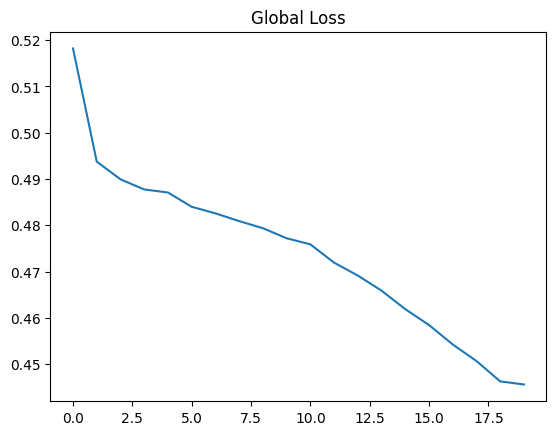

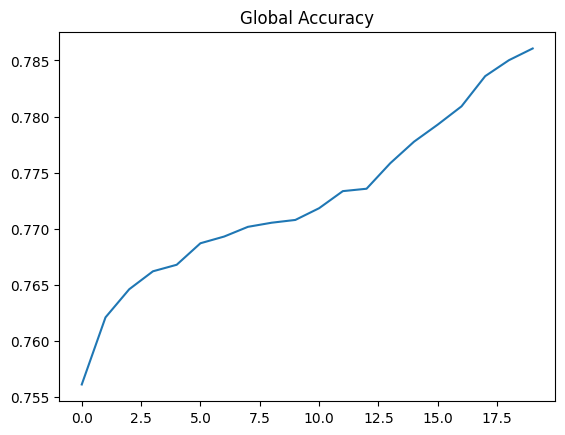

In [115]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Split data into clients
# -----------------------------
def split_clients(X, y, n_clients=5):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    return [(X[s], y[s]) for s in np.array_split(idx, n_clients)]

# -----------------------------
# 2. Build BiLSTM model
# -----------------------------
def build_bilstm(input_shape, n_classes):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=False), input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# -----------------------------
# 3. FedAvg aggregation
# -----------------------------
def fedavg(global_model, local_models, sizes):
    total = np.sum(sizes)
    new_weights = [
        sum(w * s for w, s in zip(ws, sizes)) / total
        for ws in zip(*[m.get_weights() for m in local_models])
    ]
    global_model.set_weights(new_weights)
    return global_model

# -----------------------------
# 4. FedAvg training + metrics (BiLSTM)
# -----------------------------
def model_fedavg_bilstm(xtrain, ytrain, xtest, ytest,
                        n_clients=5, rounds=5, epochs=1):

    # Convert to NumPy
    xtrain = xtrain.to_numpy() if hasattr(xtrain, "to_numpy") else np.array(xtrain)
    xtest  = xtest.to_numpy()  if hasattr(xtest, "to_numpy")  else np.array(xtest)
    ytrain = ytrain.to_numpy() if hasattr(ytrain, "to_numpy") else np.array(ytrain)
    ytest  = ytest.to_numpy()  if hasattr(ytest, "to_numpy")  else np.array(ytest)

    # Reshape for LSTM → (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0],  xtest.shape[1],  1)

    clients = split_clients(xtrain, ytrain, n_clients)
    global_model = build_bilstm(xtrain.shape[1:], len(np.unique(ytrain)))

    global_loss, global_acc = [], []

    for r in range(rounds):
        local_models, sizes = [], []

        for Xc, yc in clients:
            lm = clone_model(global_model)
            lm.set_weights(global_model.get_weights())
            lm.compile(
                optimizer=Adam(0.001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )
            lm.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(lm)
            sizes.append(len(Xc))

        global_model = fedavg(global_model, local_models, sizes)
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)

        global_loss.append(loss)
        global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    # Evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

    # Plots
    plt.figure()
    plt.plot(global_loss)
    plt.title("Global Loss per Round (BiLSTM)")
    plt.xlabel("Rounds")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(global_acc)
    plt.title("Global Accuracy per Round (BiLSTM)")
    plt.xlabel("Rounds")
    plt.ylabel("Accuracy")
    plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedavg_bilstm(
    xtrain, ytrain, xtest, ytest,
    n_clients=4, rounds=20, epochs=2
)


In [130]:
Global_Loss_per_Round_BiLSTM = [0.5182052850723267, 0.493754118680954, 0.4899359345436096, 0.487745076417923, 0.4870881140232086, 0.4840007722377777, 0.48258739709854126, 0.4809038043022156, 0.4793763756752014, 0.47720542550086975, 0.4758912920951843, 0.4719325602054596, 0.46914440393447876, 0.4658774435520172, 0.461886465549469, 0.4584598243236542, 0.4542548954486847, 0.4506770670413971, 0.4462803900241852, 0.4456101953983307]
Global_Accuracy_per_Round_BiLSTM = [0.7561405301094055, 0.7621164321899414, 0.764621376991272, 0.7662200927734375, 0.7668014764785767, 0.7687165141105652, 0.7693149447441101, 0.7701784372329712, 0.770546019077301, 0.7707939743995667, 0.7718369960784912, 0.7733587622642517, 0.7735725045204163, 0.7758466005325317, 0.7777616381645203, 0.7792834043502808, 0.7809077501296997, 0.7836008071899414, 0.7850199341773987, 0.7860629558563232]

Round 1: Loss=0.5639, Accuracy=0.7344
Round 2: Loss=0.4902, Accuracy=0.7642
Round 3: Loss=0.4896, Accuracy=0.7658
Round 4: Loss=0.4868, Accuracy=0.7660
Round 5: Loss=0.4865, Accuracy=0.7671
Round 6: Loss=0.4845, Accuracy=0.7681
Round 7: Loss=0.4835, Accuracy=0.7690
Round 8: Loss=0.4824, Accuracy=0.7692
Round 9: Loss=0.4802, Accuracy=0.7709
Round 10: Loss=0.4778, Accuracy=0.7714
Round 11: Loss=0.4758, Accuracy=0.7719
Round 12: Loss=0.4729, Accuracy=0.7734
Round 13: Loss=0.4693, Accuracy=0.7751
Round 14: Loss=0.4667, Accuracy=0.7762
Round 15: Loss=0.4624, Accuracy=0.7779
Round 16: Loss=0.4596, Accuracy=0.7777
Round 17: Loss=0.4554, Accuracy=0.7802
Round 18: Loss=0.4532, Accuracy=0.7816
Round 19: Loss=0.4483, Accuracy=0.7848
Round 20: Loss=0.4450, Accuracy=0.7855

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.74      0.78     58486
           1       0.76      0.83      0.79     58483

    accuracy                           0

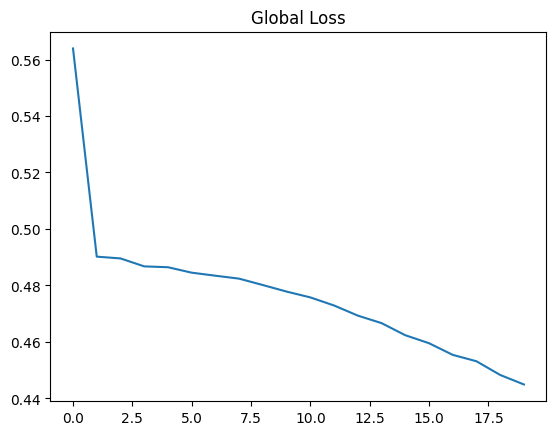

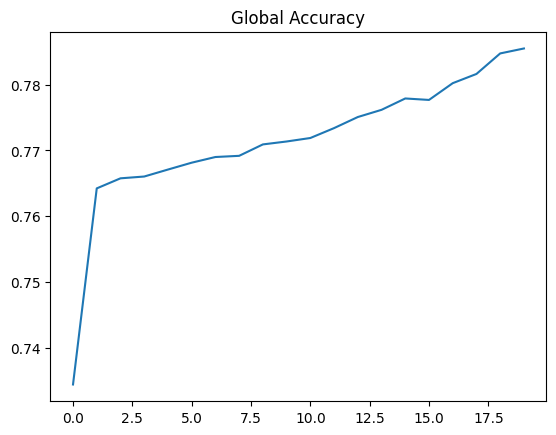

In [116]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Split data into clients
# -----------------------------
def split_clients(X, y, n_clients=5):
    idx = np.arange(len(X)); np.random.shuffle(idx)
    return [(X[s], y[s]) for s in np.array_split(idx, n_clients)]

# -----------------------------
# 2. Build GRU model
# -----------------------------
def build_gru(input_shape, n_classes):
    model = Sequential([
        GRU(64, input_shape=input_shape, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# -----------------------------
# 3. FedAvg aggregation
# -----------------------------
def fedavg(global_model, local_models, sizes):
    total = np.sum(sizes)
    new_weights = [sum(w*s for w, s in zip(ws, sizes)) / total
                   for ws in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -----------------------------
# 4. FedAvg training + metrics
# -----------------------------
def model_fedavg_gru(xtrain, ytrain, xtest, ytest, n_clients=5, rounds=5, epochs=1):

    # Convert to NumPy arrays if needed
    xtrain = xtrain.to_numpy() if hasattr(xtrain, "to_numpy") else np.array(xtrain)
    xtest  = xtest.to_numpy()  if hasattr(xtest, "to_numpy") else np.array(xtest)
    ytrain = ytrain.to_numpy() if hasattr(ytrain, "to_numpy") else np.array(ytrain)
    ytest  = ytest.to_numpy()  if hasattr(ytest, "to_numpy") else np.array(ytest)

    # Reshape to 3D for GRU: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    clients = split_clients(xtrain, ytrain, n_clients)
    global_model = build_gru(xtrain.shape[1:], len(np.unique(ytrain)))
    global_loss, global_acc = [], []

    for r in range(rounds):
        local_models, sizes = [], []
        for Xc, yc in clients:
            lm = clone_model(global_model)
            lm.set_weights(global_model.get_weights())
            lm.compile(Adam(0.001), 'sparse_categorical_crossentropy', ['accuracy'])
            lm.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(lm)
            sizes.append(len(Xc))
        global_model = fedavg(global_model, local_models, sizes)
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss); global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
    print("\nGlobal Loss per Round:", global_loss)
    print("Global Accuracy per Round:", global_acc)

    plt.figure(); plt.plot(global_loss); plt.title("Global Loss"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedavg_gru(xtrain, ytrain, xtest, ytest, n_clients=4, rounds=20, epochs=2)


In [126]:
Global_Loss_per_Round_GRU = [0.5639026165008545, 0.49021318554878235, 0.4895802438259125, 0.4867670238018036, 0.48646706342697144, 0.48453739285469055, 0.4834626317024231, 0.4824209213256836, 0.4801541566848755, 0.4778415560722351, 0.4757824242115021, 0.4729214012622833, 0.4693374037742615, 0.4666787385940552, 0.4623985290527344, 0.45957300066947937, 0.4554424285888672, 0.45317891240119934, 0.4483279585838318, 0.4449598789215088]
Global_Accuracy_per_Round_GRU = [0.7344253659248352, 0.7642366886138916, 0.765766978263855, 0.766040563583374, 0.7671006917953491, 0.7681437134742737, 0.76900714635849, 0.7691867351531982, 0.7709221839904785, 0.7713667750358582, 0.7718968391418457, 0.7734014987945557, 0.7750856876373291, 0.7761800289154053, 0.7779069542884827, 0.7776846885681152, 0.7802323698997498, 0.7816344499588013, 0.7847549319267273, 0.7855072617530823]

Round 1: Loss=0.5172, Accuracy=0.7539
Round 2: Loss=0.4901, Accuracy=0.7649
Round 3: Loss=0.4876, Accuracy=0.7666
Round 4: Loss=0.4842, Accuracy=0.7681
Round 5: Loss=0.4829, Accuracy=0.7698
Round 6: Loss=0.4814, Accuracy=0.7695
Round 7: Loss=0.4796, Accuracy=0.7705
Round 8: Loss=0.4768, Accuracy=0.7719
Round 9: Loss=0.4736, Accuracy=0.7735
Round 10: Loss=0.4710, Accuracy=0.7739
Round 11: Loss=0.4656, Accuracy=0.7760
Round 12: Loss=0.4610, Accuracy=0.7785
Round 13: Loss=0.4560, Accuracy=0.7807
Round 14: Loss=0.4524, Accuracy=0.7821
Round 15: Loss=0.4465, Accuracy=0.7849
Round 16: Loss=0.4419, Accuracy=0.7874
Round 17: Loss=0.4367, Accuracy=0.7900
Round 18: Loss=0.4333, Accuracy=0.7920
Round 19: Loss=0.4296, Accuracy=0.7942
Round 20: Loss=0.4249, Accuracy=0.7975

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78     58486
           1       0.76      0.87      0.81     58483

    accuracy                           0

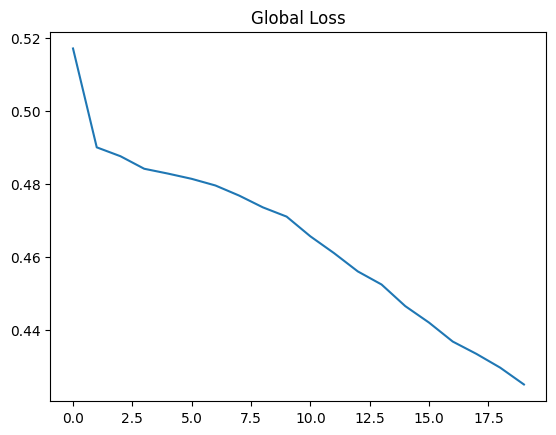

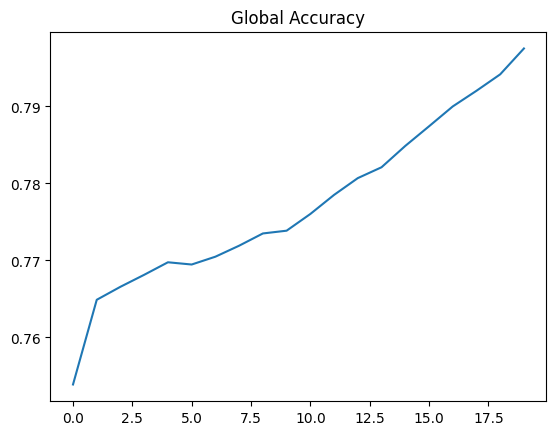

In [117]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import GRU, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Split data into clients
# -----------------------------
def split_clients(X, y, n_clients=5):
    idx = np.arange(len(X)); np.random.shuffle(idx)
    return [(X[s], y[s]) for s in np.array_split(idx, n_clients)]

# -----------------------------
# 2. Build BiGRU model
# -----------------------------
def build_bigru(input_shape, n_classes):
    model = Sequential([
        Bidirectional(GRU(64, return_sequences=False), input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# -----------------------------
# 3. FedAvg aggregation
# -----------------------------
def fedavg(global_model, local_models, sizes):
    total = np.sum(sizes)
    new_weights = [sum(w*s for w, s in zip(ws, sizes)) / total
                   for ws in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -----------------------------
# 4. FedAvg training + metrics
# -----------------------------
def model_fedavg_bigru(xtrain, ytrain, xtest, ytest, n_clients=5, rounds=5, epochs=1):

    # Convert to NumPy arrays if needed
    xtrain = xtrain.to_numpy() if hasattr(xtrain, "to_numpy") else np.array(xtrain)
    xtest  = xtest.to_numpy()  if hasattr(xtest, "to_numpy") else np.array(xtest)
    ytrain = ytrain.to_numpy() if hasattr(ytrain, "to_numpy") else np.array(ytrain)
    ytest  = ytest.to_numpy()  if hasattr(ytest, "to_numpy") else np.array(ytest)

    # Reshape to 3D for GRU: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    clients = split_clients(xtrain, ytrain, n_clients)
    global_model = build_bigru(xtrain.shape[1:], len(np.unique(ytrain)))
    global_loss, global_acc = [], []

    for r in range(rounds):
        local_models, sizes = [], []
        for Xc, yc in clients:
            lm = clone_model(global_model)
            lm.set_weights(global_model.get_weights())
            lm.compile(Adam(0.001), 'sparse_categorical_crossentropy', ['accuracy'])
            lm.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(lm)
            sizes.append(len(Xc))
        global_model = fedavg(global_model, local_models, sizes)
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss); global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
    print("\nGlobal Loss per Round:", global_loss)
    print("Global Accuracy per Round:", global_acc)

    plt.figure(); plt.plot(global_loss); plt.title("Global Loss"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedavg_bigru(xtrain, ytrain, xtest, ytest, n_clients=4, rounds=20, epochs=2)


In [124]:
Global_Loss_per_Round_BiGRU = [0.517207145690918, 0.49005967378616333, 0.48761650919914246, 0.4841787815093994, 0.4828530251979828, 0.48141002655029297, 0.47958609461784363, 0.47681209444999695, 0.47357964515686035, 0.4710390567779541, 0.4656275510787964, 0.46100425720214844, 0.4559900760650635, 0.4523971378803253, 0.4464579224586487, 0.4419410526752472, 0.43672889471054077, 0.4333377480506897, 0.4295600652694702, 0.42494261264801025]
Global_Accuracy_per_Round_BiGRU = [0.7538834810256958, 0.7648864388465881, 0.7665791511535645, 0.768135130405426, 0.7697595357894897, 0.7694688439369202, 0.7704861760139465, 0.7719139456748962, 0.7735040783882141, 0.7738631367683411, 0.7760346531867981, 0.7785139679908752, 0.7806940078735352, 0.7821046710014343, 0.7848746180534363, 0.7874222993850708, 0.7900041937828064, 0.7920389175415039, 0.7941762208938599, 0.7975360751152039]

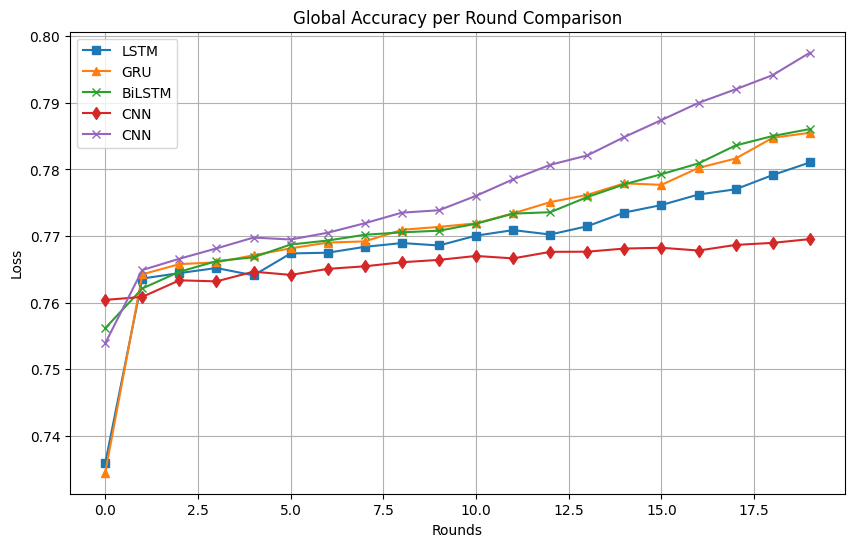

In [136]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

plt.plot(Global_Accuracy_per_Round_LSTM, marker='s', label='LSTM')
plt.plot(Global_Accuracy_per_Round_GRU, marker='^', label='GRU')
plt.plot(Global_Accuracy_per_Round_BiLSTM, marker='x', label='BiLSTM')
plt.plot(global_accuracy_per_round_CNN, marker='d', label='CNN')
plt.plot(Global_Accuracy_per_Round_BiGRU, marker='x', label='CNN')

plt.title("Global Accuracy per Round Comparison")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


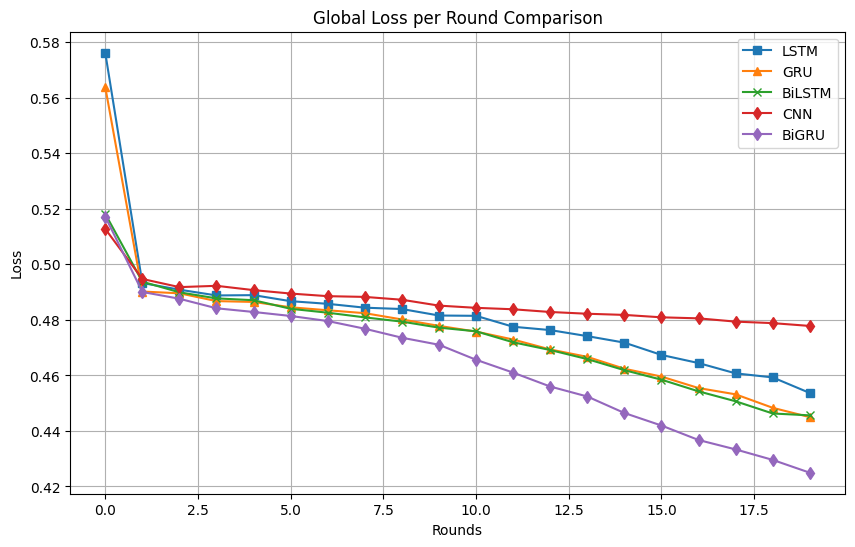

In [135]:
import matplotlib.pyplot as plt

# Plot all in one figure
plt.figure(figsize=(10,6))
plt.plot(Global_Loss_per_Round_LSTM, marker='s', label='LSTM')
plt.plot(Global_Loss_per_Round_GRU, marker='^', label='GRU')
plt.plot(Global_Loss_per_Round_BiLSTM, marker='x', label='BiLSTM')
plt.plot(global_loss_per_round_CNN, marker='d', label='CNN')
plt.plot(Global_Loss_per_Round_BiGRU, marker='d', label='BiGRU')

plt.title("Global Loss per Round Comparison")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
